In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

TODO:
1) X - Save Models
2) X train from script
3) X Subset fragment lengths
4) X explore variance of counts
5) Add jitter
6) add count head
7) X Don't filter out duplicates in frag h5 creation
8) X Only fit forward starts and reverse ends

In [2]:
import os

import pandas as pd
import pysam

from tqdm.notebook import tqdm
tqdm.pandas()

from fragmentomics_tools.dataframe import RegionDataFrame, SampleAndRegionDataFrame
from fragmentomics_tools.bias_correction.train import build_rdfs
from fragmentomics_tools.bias_correction.model import BackgroundModelModule
from fragmentomics_tools.bias_correction.data import FragmentEndpointsDataset

In [3]:
%%time
train_rdf, val_rdf, test_rdf = build_rdfs()

CPU times: user 12.2 s, sys: 2.28 s, total: 14.5 s
Wall time: 13.1 s


In [353]:
import glob
sample_ids = [x.split("/")[-1].split(".")[2] for x in glob.glob("/scratch/karius/bias_correction_model/merged.negative_binomial.RD-*.2.res")]
sample_ids

['RD-56154',
 'RD-56155',
 'RD-56164',
 'RD-56171',
 'RD-56162',
 'RD-56163',
 'RD-56153',
 'RD-56165',
 'RD-56156',
 'RD-56173',
 'RD-56169',
 'RD-56161',
 'RD-56150',
 'RD-56168',
 'RD-56170',
 'RD-56172',
 'RD-56167',
 'RD-56166']

In [354]:
load_ibd_sample_df().query("sample_id in @sample_ids")

,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER
89,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13
88,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13
87,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13
86,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13
84,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13
85,RD-56166,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13
0,RD-56150,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 1,Site_13
1,RD-56153,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 2,Site_13
2,RD-56154,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 4,Site_13
3,RD-56155,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 3,Site_13


In [207]:
val_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(val_rdf, load_ibd_sample_df().query("sample_id in @sample_ids"))

In [208]:
test_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(test_rdf, load_ibd_sample_df().query("sample_id in @sample_ids"))

In [355]:
%%time
dfs = []
for i, sample_id in enumerate(sample_ids):
    print(i, len(sample_ids))
    model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.{sample_id}.2.res').cpu()
    pred = model.predict_from_rdf(val_rdf)
    fwd_pred = pred.fwd_start_counts_dist.progress_apply(lambda x: x.mean().sum()).rename("fwd_pred")
    rev_pred = pred.bkwd_stop_counts_dist.progress_apply(lambda x: x.mean().sum()).rename("rev_pred")
    pred_ratio = pd.DataFrame((rev_pred/(fwd_pred + rev_pred)).rename('pred_ratio'))
    pred_ratio['sample_id'] = sample_id
    pred_ratio = pd.DataFrame(test_rdf)[['gene_name']].join(pred_ratio)
    dfs.append(pred_ratio)

0 18


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 877.84it/s]


1 18


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 893.45it/s]


2 18


...

16 18


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 874.79it/s]


17 18


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 868.45it/s]

CPU times: user 6min 53s, sys: 3.54 s, total: 6min 57s
Wall time: 1min 49s


In [356]:
pred_df = pd.concat(dfs)

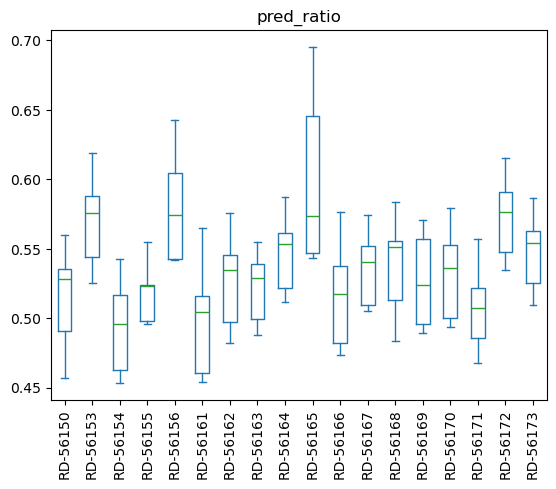

In [357]:
_ = pred_df.plot.box(by="sample_id", rot=90)

In [358]:
sdf.query("sample_id == @sample_id"), sample_id

(   sample_id  label                                            frag_h5  \
 85  RD-56166      1  <fragments_h5.fragments_h5.FragmentsH5 object ...   
 
              DIAGNOSIS ENDO_CATEGORY           Cluster SITE_NUMBER  
 85  Ulcerative Colitis     Remission  Patient Group  3     Site_13  ,
 'RD-56166')

In [359]:
%%time
all_stats = {}
# res = {}
for i, sample_id in enumerate(sample_ids):
    print(i+1, len(sample_ids), sample_id)
    model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.merged.2.res').cpu()
    tmp = model.predict_from_rdf_and_sdf(val_rdf.attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz"), load_ibd_sample_df().query("sample_id == @sample_id"))
    stats = tmp.build_stats_df()
    all_stats[sample_id] = stats
    # res[sample_id] = (stats.bkwd_stop_counts_count/(stats.bkwd_stop_counts_count + stats.fwd_start_counts_count))SipsTea/comments/1bwf0x4/that_random_gym_fat_dude_is_always_surprisingly/

1 18 RD-56154
Predicting dists (1/5)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1033.20it/s]


Building fragment arrays (2/5)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 47.74it/s]


Merging fragment arrays (3/5)


...

Building observed arrays (4/5)
Building observed arrays (4/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 681.87it/s]


Merging Results (5/5)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:31<00:00,  6.27it/s]

CPU times: user 18min 10s, sys: 20.6 s, total: 18min 30s
Wall time: 12min 45s


In [360]:
all_dfs = []
for key, sub_df in all_stats.items():
    sub_df['sample_id'] = key
    all_dfs.append(sub_df)
stats_merged_df = pd.concat(all_dfs).set_index("sample_id")
stats_merged_df = stats_merged_df.query("fwd_start_counts_count > 50")

In [361]:
stats_merged_df.head()

,index,gene_id,gene_name,fwd_start_counts_count,fwd_start_counts_pred_count,fwd_start_counts_l1_loss,fwd_start_counts_frac_over_95_conf,fwd_start_counts_frac_over_99_conf,bkwd_stop_counts_count,bkwd_stop_counts_pred_count,bkwd_stop_counts_l1_loss,bkwd_stop_counts_frac_over_95_conf,bkwd_stop_counts_frac_over_99_conf
sample_id,,,,,,,,,,,,,
RD-56154,0,ENSG00000188984,AADACL3,75.0,833.395091,0.053424,0.002807,0.000060,83.0,1134.780873,0.071209,0.002448,0.000239
RD-56154,1,ENSG00000203727,SAMD5,322.0,3678.364663,0.060001,0.002843,0.000061,336.0,3981.590253,0.064814,0.002537,0.000031
RD-56154,2,ENSG00000182168,UNC5C,2127.0,24628.841913,0.067201,0.002717,0.000033,2019.0,22532.032667,0.061668,0.002786,0.000028
RD-56154,3,ENSG00000146648,EGFR,752.0,8358.985419,0.062633,0.002718,0.000049,777.0,8121.985328,0.061294,0.002633,0.000077
RD-56154,5,ENSG00000169418,NPR1,134.0,1402.306428,0.075044,0.002113,0.000103,104.0,969.371575,0.053288,0.002010,0.000052


0    Axes(0.125,0.11;0.775x0.77)
dtype: object

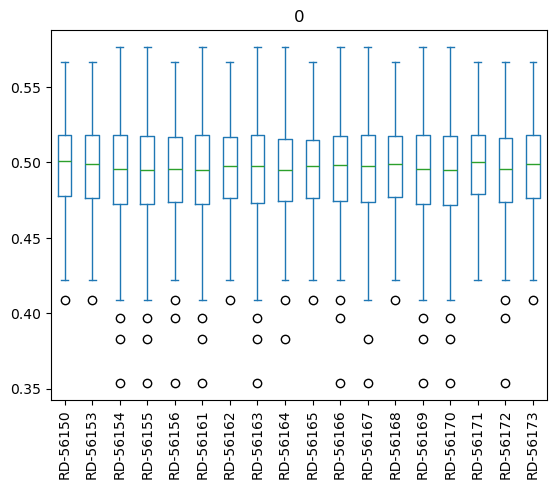

In [363]:
(stats_merged_df.bkwd_stop_counts_pred_count/(stats_merged_df.bkwd_stop_counts_pred_count + stats_merged_df.fwd_start_counts_pred_count)).reset_index().plot.box(by='sample_id', rot=90)

0    Axes(0.125,0.11;0.775x0.77)
dtype: object

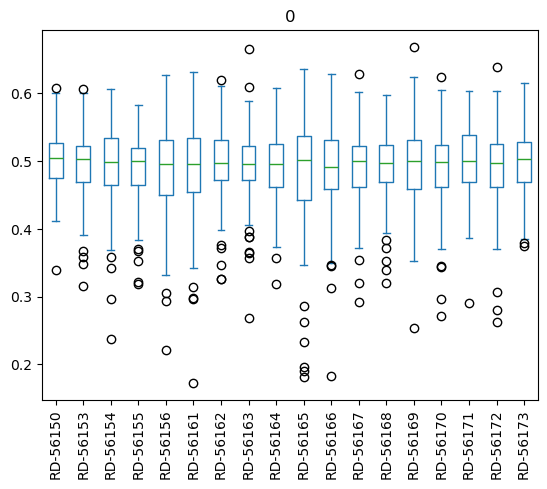

In [364]:
(stats_merged_df.bkwd_stop_counts_count/(stats_merged_df.bkwd_stop_counts_count + stats_merged_df.fwd_start_counts_count)).reset_index().plot.box(by='sample_id', rot=90)

0    Axes(0.125,0.11;0.775x0.77)
dtype: object

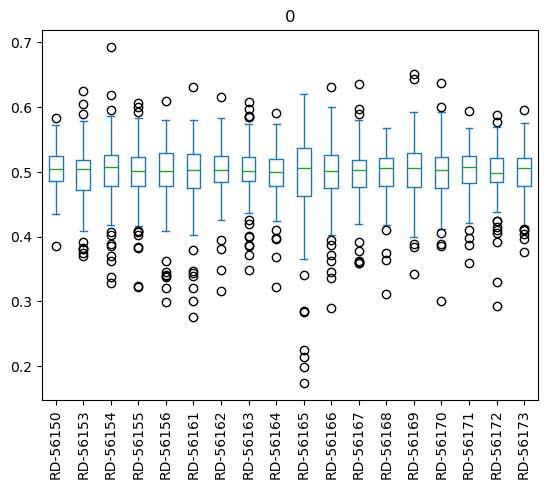

In [365]:
bkwd_cnts = stats_merged_df.bkwd_stop_counts_count/stats_merged_df.bkwd_stop_counts_pred_count
fwd_cnts = stats_merged_df.fwd_start_counts_count/stats_merged_df.fwd_start_counts_pred_count
(bkwd_cnts/(bkwd_cnts + fwd_cnts)).reset_index().plot.box(by='sample_id', rot=90)

sample_id
RD-56166    200
Name: count, dtype: int64


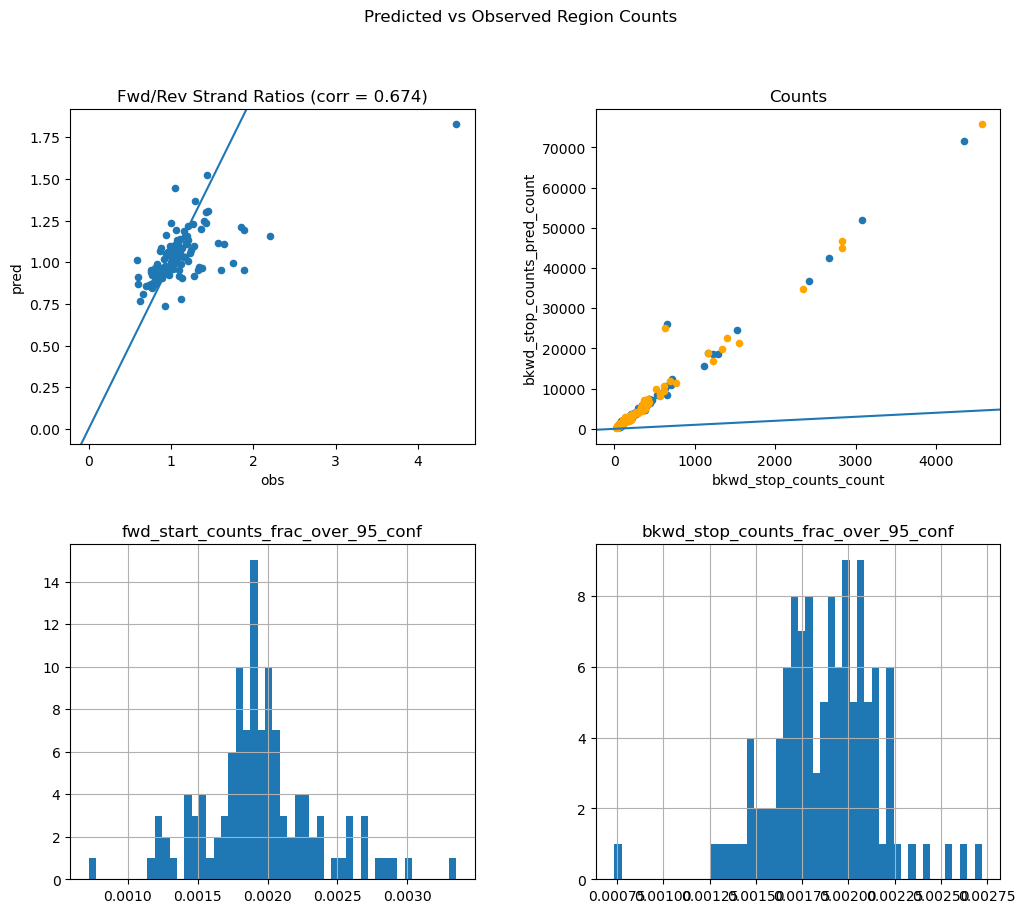

In [370]:
def plot(index):
    print(all_dfs[index].sample_id.value_counts())
    all_dfs[index].query("fwd_start_counts_count > 50").dropna().make_qc_plots()

plot(17)

In [185]:
ratios_df = pd.DataFrame(test_srdf).join(obs_ratio).set_index(["gene_name", "sample_id"]).join(pred_df.set_index(['gene_name', 'sample_id']))[['label', 'direction', 'avg_log2FC', 'obs_ratio', 'pred_ratio']]

NameError: name 'obs_ratio' is not defined

In [ ]:
ratios_df

In [ ]:
ratios_df[['obs_ratio']].groupby('gene_name').mean().sort_values(by='obs_ratio').tail(5) # 'pred_ratio'

In [ ]:
tmp = ratios_df.groupby(['label', 'sample_id', 'direction']).median()
tmp.pred_ratio.sort_values().reset_index()[['direction', 'label', 'pred_ratio']].boxplot(by=['direction', 'label'], rot=90, figsize=(10, 4))

In [ ]:
pd.DataFrame(srdf)[['gene_name', 'label']].join(obs_ratio).head(18).sort_values('label')

In [9]:
from lib import load_ibd_sample_df
sdf = load_ibd_sample_df() # .query("sample_id == 'RD-56170'")

In [20]:
from ibd.data import HematopoieticGeneExpression
hge_raw = HematopoieticGeneExpression.load().expand_regions(2048, 2048).attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz")

In [ ]:
def plot_real_params():
    sample_id = sample_ids[0]
    model = BackgroundModelModule.load('/scratch/karius/bias_correction_model/merged.negative_binomial.RD-56170.1.res').cpu()
    val_dataset = FragmentEndpointsDataset(val_rdf, sdf.query("sample_id == @sample_id"), model)
    pd.DataFrame(model.model(val_dataset[0][0].cpu()).cpu().detach()).T.hist(sharex=True)

In [ ]:
plot_real_params()

In [167]:
sample_id = "RD-56169"
# sample_id = "merged"
# /scratch/karius/bias_correction_model/merged.negative_binomial.base_model.3.res
# model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/{sample_id}.two_residual.negative_binomial.2.res').cpu()
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.{sample_id}.2.res').cpu()

In [197]:
hge_raw.query("gene_name == 'TYK2'")

,gene_name,gene_id,contig,strand,start,stop,expression,blacklist_regions
15888,TYK2,ENSG00000105397,chr19,-,10348481,10368628,43.462897,"[chr19:10349386-10349417, chr19:10352697-10352..."


In [198]:
res = model.predict_from_rdf_and_sdf(hge_raw.query("gene_name == 'TYK2'"), (sdf if sample_id == 'merged' else sdf.query("sample_id == @sample_id")))

Predicting dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 652.40it/s]


Building fragment arrays (2/5)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.19s/it]


Merging fragment arrays (3/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 548.63it/s]


Building observed arrays (4/5)
Building observed arrays (4/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 415.98it/s]

Merging Results (5/5)


In [171]:
test_rdf = test_rdf.drop(columns='blacklist_regions').attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz")

(<Figure size 2500x1800 with 9 Axes>,
 [<Axes: >,
  <Axes: title={'center': 'fwd_start_counts'}>,
  <Axes: title={'center': 'smoothed_ratio'}>,
  <Axes: title={'center': 'log10(1+count)'}>,
  <Axes: title={'center': 'bkwd_stop_counts'}>,
  <Axes: title={'center': 'smoothed_ratio'}>,
  <Axes: title={'center': 'log10(1+count)'}>,
  <Axes: >,
  <Axes: xlabel='chr19'>])

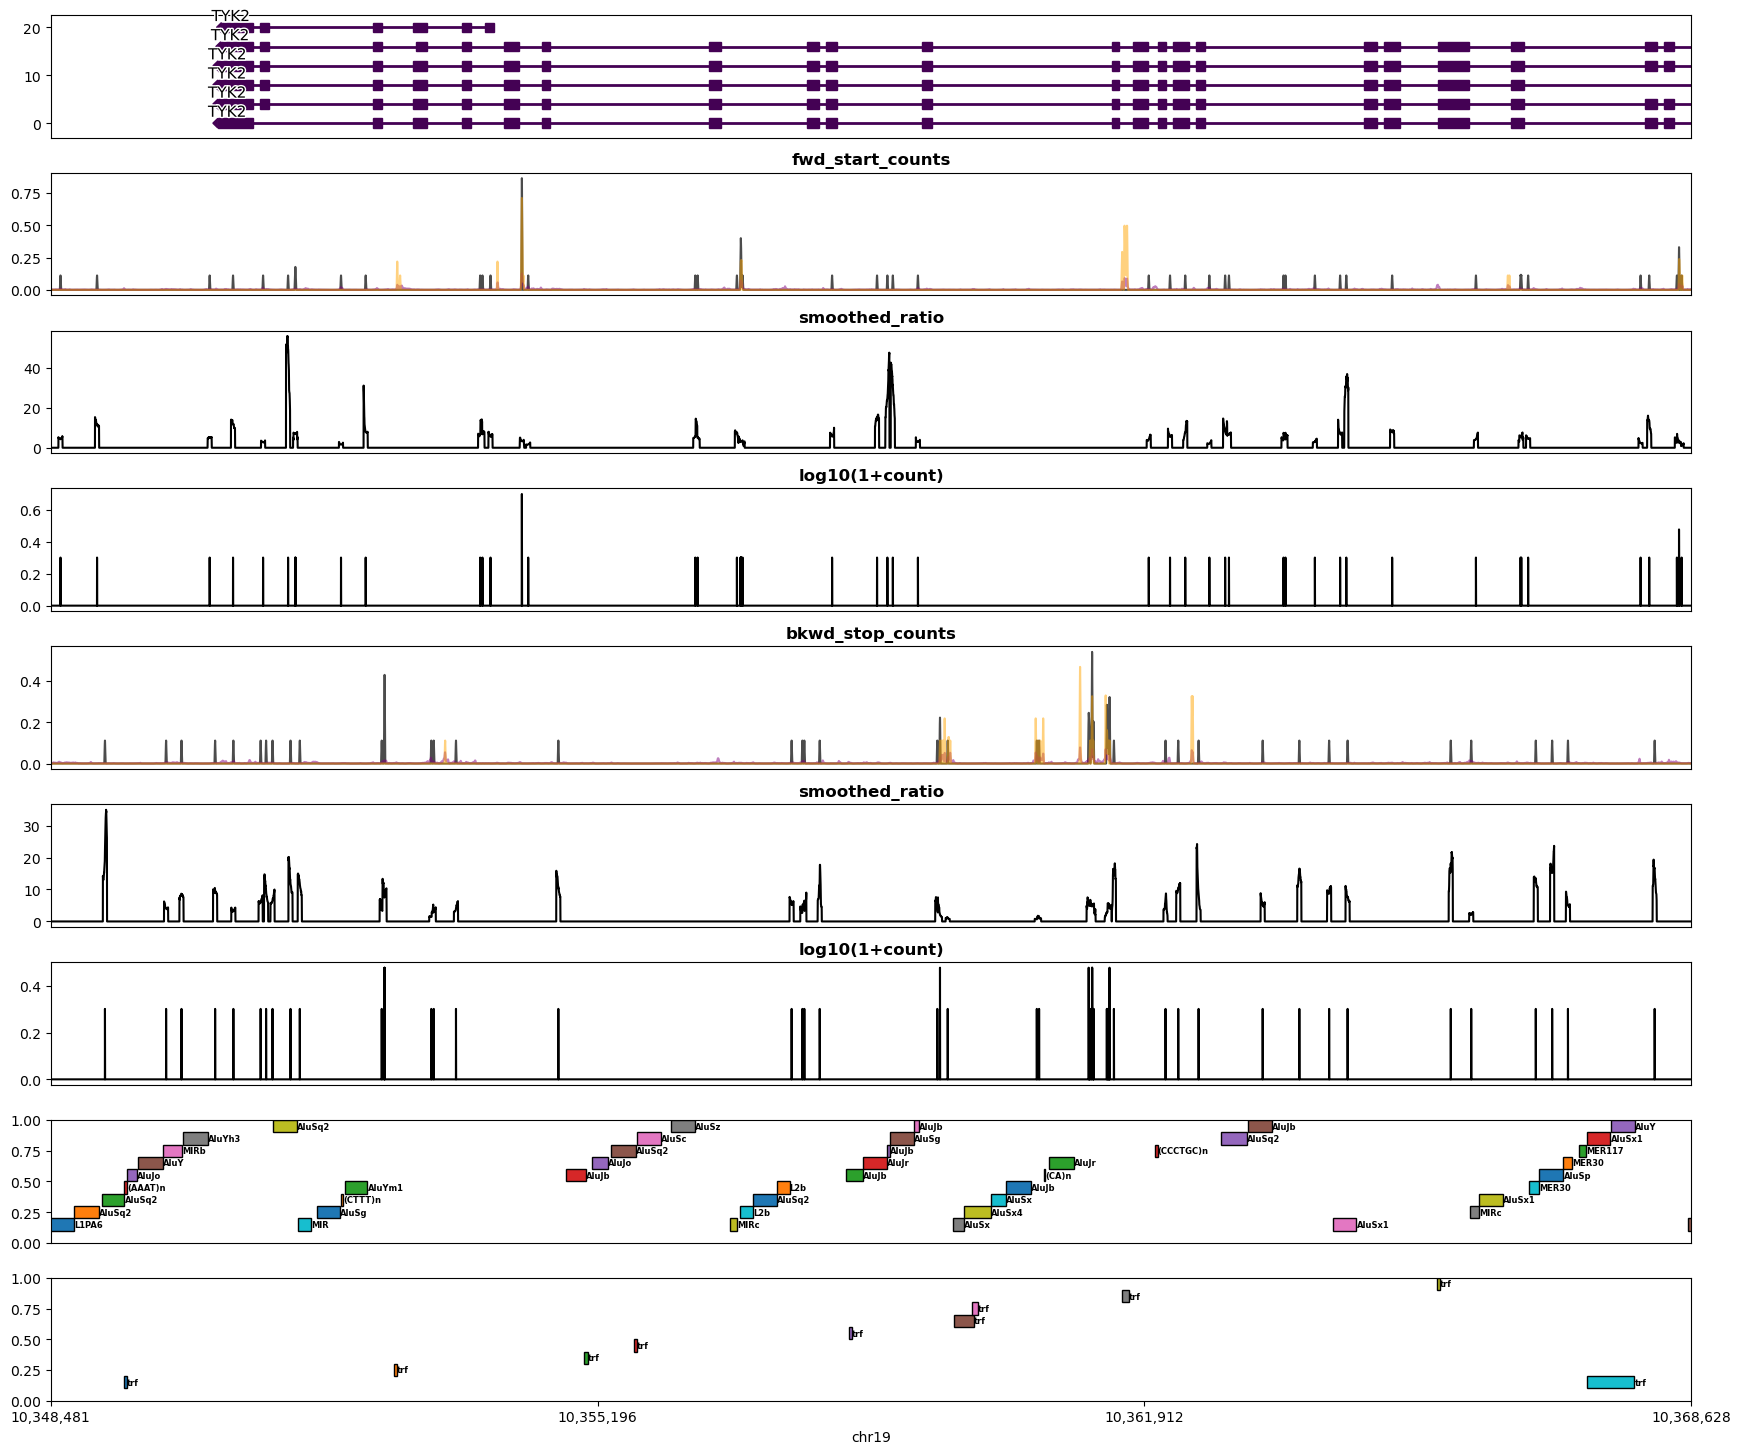

In [199]:
res.make_tracks_for_gene('TYK2', max_scale=False, smooth=50).plot()

In [172]:
dists_and_counts = model.predict_from_rdf_and_sdf(test_rdf, (sdf if sample_id == 'merged' else sdf.query("sample_id == @sample_id")))

Predicting dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 788.52it/s]


Building fragment arrays (2/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 643.40it/s]


Merging fragment arrays (3/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 608.34it/s]


Building observed arrays (4/5)
Building observed arrays (4/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 484.17it/s]

Merging Results (5/5)


In [173]:
stats = dists_and_counts.build_stats_df()

 33%|██████████████████████████████▉                                                                | 121/371 [00:04<00:11, 21.85it/s]WARNING	2024-04-04 20:46:38,054	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:368: RuntimeWarning: divide by zero encountered in _nbinom_skewness
  _boost._nbinom_skewness(n, p),

WARNING	2024-04-04 20:46:38,056	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:369: RuntimeWarning: divide by zero encountered in _nbinom_kurtosis_excess
  _boost._nbinom_kurtosis_excess(n, p),

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:13<00:00, 27.19it/s]


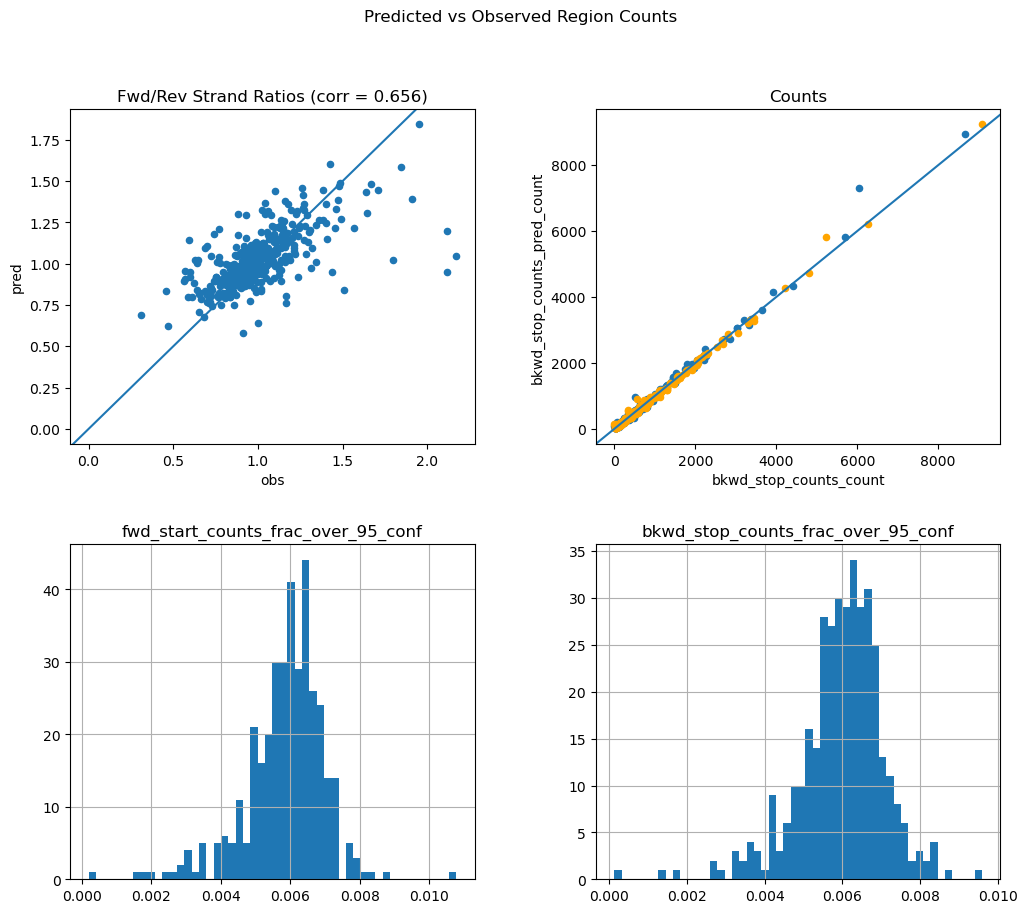

In [174]:
stats.make_qc_plots()

# Negative Binomial Fit 

In [447]:
import statsmodels.formula.api as smf

In [448]:
def initial_dist(counts):
    nbdata = pd.DataFrame({"nbdata": counts})
    nbfit = smf.negativebinomial("nbdata ~ 1", data=nbdata).fit_regularized()
    n, p = convert_params(nbdata.values.mean(), nbfit.params[1])
    return nbinom(n=n, p=p)

In [449]:
def qc_dist(data):
    dist = initial_dist(data)
    print(dist.kwds)
    print(dist.mean(), data.mean())
    print(dist.std(), data.std())
    pred = pd.DataFrame(dist.rvs(len(tmp.iloc[0].fwd_start_counts))).value_counts().rename('pred')
    obs = pd.DataFrame(tmp.iloc[0].fwd_start_counts.astype(int)).value_counts().rename("obs")# , obs=tmp.iloc[0].fwd_start_counts)).value_counts()
    return pd.DataFrame(obs).join(pred).fillna(0).sort_index() # .plot.scatter(x='obs', y='pred')

In [450]:
qc_dist(data = tmp.iloc[10].fwd_start_counts).head(50)

AttributeError: 'Series' object has no attribute 'fwd_start_counts'

In [451]:
dist = tmp.iloc[0].fwd_start_counts_dist
pd.DataFrame(dict(p=dist.kwds['p'], n=dist.kwds['n'])).hist(figsize=(20, 5), bins=50)

AttributeError: 'Series' object has no attribute 'fwd_start_counts_dist'

In [37]:
test_rdf

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction
0,ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon
1,ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon
2,ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon
3,ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon
4,ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon
...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon
367,WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon
368,XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon
369,ZBTB7C,ENSG00000184828,chr18,-,48024624,48043171,0.258426,0.000000e+00,-3.593996,0.023,0.414,0.000000e+00,up_in_colon


In [52]:
test_rdf.index

RangeIndex(start=0, stop=371, step=1)

In [49]:
mask_regions = {gene_name: [] for gene_name in test_rdf.gene_name.tolist()}
for region, record in test_rdf[['contig', 'start', 'stop', 'strand', 'gene_name']].intersect_with_bed("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz").iter_region_row():
    mask_regions[record.gene_name].append(region)

In [51]:
test_rdf.set_index("gene_name").join(pd.Series(mask_regions).rename("repeat_regions"))

,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction,repeat_regions
gene_name,,,,,,,,,,,,,
ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon,"[chr2:168921844-168921879, chr2:168921846-1689..."
ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon,[]
ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon,"[chr16:16149372-16149403, chr16:16155566-16155..."
ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon,"[chr17:7341211-7341387, chr17:7342907-7342932,..."
ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon,"[chr3:123301830-123301869, chr3:123303833-1233..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon,"[chr17:42789665-42789710, chr17:42790006-42790..."
WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon,"[chr1:227918042-227918431, chr1:227918044-2279..."
XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon,"[chr2:31334210-31334236, chr2:31338714-3133874..."


In [138]:
test_rdf.set_index(['gene_name', 'gene_id']).reset_index()

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction
0,ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon
1,ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon
2,ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon
3,ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon
4,ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon
...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon
367,WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon
368,XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon
369,ZBTB7C,ENSG00000184828,chr18,-,48024624,48043171,0.258426,0.000000e+00,-3.593996,0.023,0.414,0.000000e+00,up_in_colon


In [185]:
tmp = test_rdf.set_index('gene_name').intersect_with_rdf(RegionDataFrame.from_bed("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", ref='hg38')[['contig', 'start', 'stop', 'strand']])
blacklist_regions = tmp.reset_index().groupby(tmp.index.names).apply(lambda x: list(x.iter_regions()))

In [200]:
test_rdf.set_index("gene_name").join(blacklist_regions.rename("blacklist_regions")).fillna('')

,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction,blacklist_regions
gene_name,,,,,,,,,,,,,
ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon,"[chr2:-:168918733-169020200, chr2:-:168918733-..."
ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon,
ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon,"[chr16:-:16147517-16225515, chr16:-:16147517-1..."
ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon,"[chr17:+:7334481-7353525, chr17:+:7334481-7353..."
ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon,"[chr3:-:123280248-123370094, chr3:-:123280248-..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon,"[chr17:+:42778562-42799114, chr17:+:42778562-4..."
WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon,"[chr1:-:227916608-227949980, chr1:-:227916608-..."
XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon,"[chr2:-:31332273-31416790, chr2:-:31332273-314..."


In [95]:
bed_columns = ['contig', 'start', 'stop', 'strand']
columns = bed_columns + [c for c in test_rdf.columns if c not in bed_columns]

In [81]:
test_rdf

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction,blacklist_regions
0,ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon,"[chr2:168921844-168921879, chr2:168921846-1689..."
1,ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon,
2,ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon,"[chr16:16149372-16149403, chr16:16155566-16155..."
3,ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon,"[chr17:7341211-7341387, chr17:7342907-7342932,..."
4,ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon,"[chr3:123301830-123301869, chr3:123303833-1233..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon,"[chr17:42789665-42789710, chr17:42790006-42790..."
367,WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon,"[chr1:227918042-227918431, chr1:227918044-2279..."
368,XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon,"[chr2:31334210-31334236, chr2:31338714-3133874..."
369,ZBTB7C,ENSG00000184828,chr18,-,48024624,48043171,0.258426,0.000000e+00,-3.593996,0.023,0.414,0.000000e+00,up_in_colon,"[chr18:48032104-48032750, chr18:48032422-48032..."
